# Exp7.2.6.2 — Mean-CE output-bias ablation

Analysis-only notebook. It reads finalized aggregate artifacts and does not train or run inference.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    path = (start or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'pyproject.toml').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root')

REPO_ROOT = find_repo_root()
root = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_7_2_6_2_mean_ce_bias' / 'mean_ce_bias_v1'
native = pd.read_csv(root / 'native_performance_summary.csv')
decomp = pd.read_csv(root / 'bias_effect_decomposition_summary.csv')
probes = pd.read_csv(root / 'l2_probe_summary.csv')
probe_delta = pd.read_csv(root / 'l2_probe_delta_summary.csv')
bias_diag = pd.read_csv(root / 'bias_diagnostics_summary.csv')
bias_values = pd.read_csv(root / 'bias_values.csv')
history = pd.read_csv(root / 'training_history_summary.csv')

## 1. Native BA: no-bias vs bias-trained

In [2]:
display(native[native['split'] == 'test'].sort_values('condition'))

,condition,split,n,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,objective_loss_mean,objective_loss_std
0,mean_ce_bias0_reuse,test,3,0.559361,0.008543,0.545353,0.010733,0.534890,0.020428,1.456758,0.075157
3,mean_ce_bias1_with_bias,test,3,0.534247,0.029592,0.516879,0.038850,0.495276,0.053425,1.494082,0.149931
6,mean_ce_bias1_zero_bias,test,3,0.529680,0.035517,0.513527,0.041715,0.494183,0.057443,1.501705,0.153616


## 2. Exact bias-effect decomposition

Total effect = direct readout effect + E2E training effect.

In [3]:
display(decomp.sort_values('split'))

,split,n,no_bias_ba_mean,no_bias_ba_std,bias_trained_with_bias_ba_mean,bias_trained_with_bias_ba_std,bias_trained_zero_bias_ba_mean,bias_trained_zero_bias_ba_std,total_bias_effect_mean,total_bias_effect_std,direct_readout_effect_mean,direct_readout_effect_std,e2e_training_effect_mean,e2e_training_effect_std,decomposition_error_mean,decomposition_error_std
0,test,3,0.545353,0.010733,0.516879,0.038850,0.513527,0.041715,-0.028475,0.028605,0.003352,0.007062,-0.031827,0.031050,0.0,0.0
1,train,3,0.851709,0.073302,0.818682,0.153104,0.812971,0.160394,-0.033028,0.094343,0.005710,0.007332,-0.038738,0.101450,0.0,0.0
2,val,3,0.558728,0.038638,0.560219,0.050794,0.520459,0.062119,0.001491,0.016876,0.039761,0.014066,-0.038270,0.024162,0.0,0.0


## 3. L2 representation accessibility

In [4]:
display(probes[probes['split'] == 'test'].sort_values(['probe', 'condition']))
display(probe_delta.sort_values('probe'))

,condition,probe,split,n,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std
0,mean_ce_bias0_reuse,l2_fixed250_linear,test,3,0.609589,0.034925,0.596010,0.035544,0.595646,0.037730
9,mean_ce_bias1_with_bias,l2_fixed250_linear,test,3,0.593607,0.031800,0.579992,0.032227,0.583826,0.033326
3,mean_ce_bias0_reuse,l2_wholecount_linear,test,3,0.568493,0.025628,0.557635,0.022399,0.547807,0.028555
12,mean_ce_bias1_with_bias,l2_wholecount_linear,test,3,0.563927,0.021173,0.551811,0.024416,0.540714,0.031168
6,mean_ce_bias0_reuse,l2_wholecount_matched_biasfree,test,3,0.474886,0.025830,0.471304,0.022317,0.470853,0.023199
15,mean_ce_bias1_with_bias,l2_wholecount_matched_biasfree,test,3,0.449772,0.017977,0.443812,0.015687,0.438630,0.016693


,probe,n,no_bias_test_ba_mean,no_bias_test_ba_std,bias_trained_test_ba_mean,bias_trained_test_ba_std,bias_trained_minus_no_bias_mean,bias_trained_minus_no_bias_std
0,l2_fixed250_linear,3,0.596010,0.035544,0.579992,0.032227,-0.016018,0.013069
1,l2_wholecount_linear,3,0.557635,0.022399,0.551811,0.024416,-0.005824,0.026510
2,l2_wholecount_matched_biasfree,3,0.471304,0.022317,0.443812,0.015687,-0.027492,0.033164


## 4. Learned bias diagnostics

In [5]:
display(bias_diag.sort_values('split'))
display(bias_values.sort_values(['class_label', 'seed']))

,split,n,prediction_change_fraction_mean,prediction_change_fraction_std,zero_wrong_to_with_correct_fraction_mean,zero_wrong_to_with_correct_fraction_std,zero_correct_to_with_wrong_fraction_mean,zero_correct_to_with_wrong_fraction_std,bias_l2_mean,bias_l2_std,bias_abs_mean_mean,bias_abs_mean_std,bias_std_mean,bias_std_std,bias_range_mean,bias_range_std,mean_zero_bias_logit_l2_mean,mean_zero_bias_logit_l2_std,bias_l2_to_mean_zero_logit_l2_mean,bias_l2_to_mean_zero_logit_l2_std
0,test,3,0.047945,0.005592,0.018265,0.006458,0.013699,0.005592,0.364568,0.062633,0.091061,0.015501,0.105121,0.018039,0.350595,0.069888,8.343674,1.809526,0.044231,0.002493
1,train,3,0.045898,0.035948,0.017785,0.016648,0.009753,0.006641,0.364568,0.062633,0.091061,0.015501,0.105121,0.018039,0.350595,0.069888,8.057204,1.875185,0.046076,0.003601
2,val,3,0.097884,0.020831,0.058201,0.009899,0.013228,0.003741,0.364568,0.062633,0.091061,0.015501,0.105121,0.018039,0.350595,0.069888,7.533213,1.737339,0.049237,0.003677


,seed,class_index,class_label,bias
0,11,0,A,-0.150900
12,23,0,A,-0.109759
24,37,0,A,-0.161747
1,11,1,B,-0.056204
13,23,1,B,-0.052194
25,37,1,B,-0.046336
2,11,2,C,0.158859
14,23,2,C,0.088950
26,37,2,C,0.119305
3,11,3,D,0.016021


## 5. Aggregate validation curves

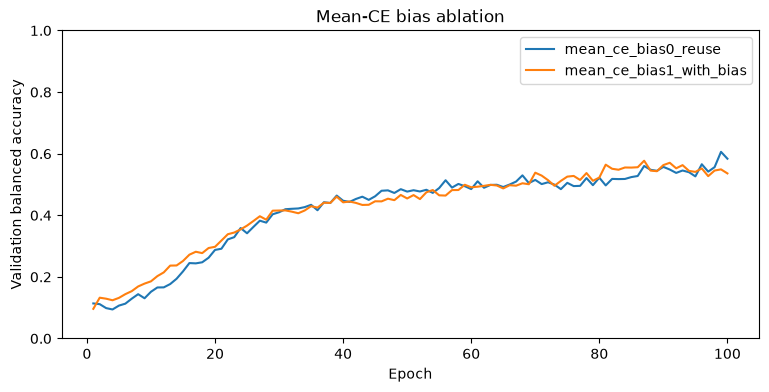

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
for condition, frame in history.groupby('condition'):
    if 'val_ba_mean' in frame.columns:
        ax.plot(frame['epoch'], frame['val_ba_mean'], label=condition)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation balanced accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Mean-CE bias ablation')
plt.show()